# PBI Database Exploration and Quality Control

This notebook serves as a comprehensive guide for exploring the PBI (Phage-Bacteria Interaction) database, understanding data quality, and visualizing database composition.

## What You'll Learn
1. **Database Connection** - Connect to PBI using `quick_connect()` and explore its structure
2. **Database Statistics** - Overview of phage, host, and association counts
3. **Source Database Distribution** - Which databases contribute phages
4. **Host Genome Coverage** - Hosts mentioned in phage records vs. hosts with downloadable genomes
5. **Phage Quality** - Completeness, lifestyle, genome length, and GC content distributions
6. **Host Taxonomy** - Host species diversity and assembly quality
7. **Phage-Host Pairs** - Properties of known phage-host interactions
8. **Understanding Warnings** - How to interpret missing sequence warnings

## About PBI
PBI aggregates phage-host interaction data from multiple databases (INPHARED, PhagesDB, NCBI, etc.) into a unified DuckDB database with associated FASTA sequence files. Not every phage has a sequenced host genome, and not every host has a downloadable genome — this is **expected and normal**.

## Setup & Imports

We import standard data science libraries plus the `pbi` package. The `sys.path.insert` ensures the package is found when running from the notebooks directory.

In [15]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pbi
from pbi import quick_connect

# Visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Packages imported successfully")

Packages imported successfully


## Database Connection

`pbi.quick_connect()` auto-detects the database path and all FASTA files. It returns a `SequenceRetriever` object that provides:
- **Metadata queries** via DuckDB (fast SQL access)
- **Sequence retrieval** via indexed FASTA files (pyfaidx random access)
- **Dataset creation** for ML workflows

The connection is fast because FASTA indexes are pre-built — sequences are only loaded on demand.

In [16]:
# Connect to the database
retriever = quick_connect()
print("Connected to database")

# Get database statistics
stats = retriever.get_stats()
print("\n Database Statistics:")
for category, values in stats.items():
    print(f"\n{category.upper()}:")
    for key, value in values.items():
        if isinstance(value, (int, float)):
            print(f"  {key}: {value:,}")
        else:
            print(f"  {key}: {value}")

2026-04-15 11:01:56,692 - INFO - 📂 Checking FASTA index files:
2026-04-15 11:01:56,696 - INFO -    Phage index: True (52570.4 KB)
2026-04-15 11:01:56,704 - INFO -    Protein index: True (1432185.2 KB)
2026-04-15 11:01:56,707 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-04-15 11:01:56,720 - INFO -    Loaded mapping for 5537 hosts
2026-04-15 11:01:56,722 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-04-15 11:01:56,782 - INFO - 🔄 Starting background FASTA loading...
2026-04-15 11:01:56,783 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-04-15 11:01:56,784 - INFO - ✅ Initialization complete (FASTA loading in background)
2026-04-15 11:01:57,590 - INFO - ⏳ Waiting for FASTA loading to complete...


Connected to database


2026-04-15 11:02:30,847 - INFO -    ✅ Phage FASTA loaded in 34.06s (873,717 sequences)
2026-04-15 11:02:30,848 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta
2026-04-15 11:06:57,694 - WARNING - ⚠️ Timeout after 300s - FASTA may still be loading
2026-04-15 11:08:52,717 - INFO -    ✅ Protein FASTA loaded in 381.87s (31,050,116 sequences)
2026-04-15 11:08:52,718 - INFO -    ℹ️  Using on-demand loading for 5,537 individual host files
2026-04-15 11:08:52,719 - INFO - 🎉 All FASTA files loaded in 415.94s
2026-04-15 11:09:01,847 - INFO - 🔍 Sample phage keys:
2026-04-15 11:09:01,848 - INFO -    - 'AE002163.1...'
2026-04-15 11:09:01,849 - INFO -    - 'AF009630.1...'
2026-04-15 11:09:01,851 - INFO -    - 'AF011378.1...'
2026-04-15 11:09:01,852 - INFO - 🔍 Sample protein keys:
2026-04-15 11:09:01,853 - INFO -    - 'AE002163.1 AAF39720.1...'
2026-04-15 11:09:01,854 - INFO -    - 'AE002163.1 AAF39721.1...'
2026-04-15 11:09:01,855 - INFO -    - 'AE002163.1 


 Database Statistics:

DATABASE:
  phages: 873,718
  proteins: 43,088,582
  hosts: 5,542
  phage_host_associations: 782,068

FASTA:
  phages: 873,717
  proteins: 31,050,116
  hosts: 5,537


## Database Statistics Overview

The statistics above show:
- **database.phages**: Total phage records in the database
- **database.hosts**: Host bacterial genomes with metadata
- **database.phage_host_associations**: Known phage-host infection pairs
- **fasta.phages / fasta.proteins**: Sequences available in FASTA files

Note: `fasta.phages` may differ from `database.phages` — not all phages have a downloaded sequence file.

## 1. Phage Entries per Source Database

The PBI database aggregates phages from multiple sources. Understanding the source distribution helps identify which databases contribute most data and assess potential biases.

**Common sources include:**
- **INPHARED**: Large curated phage database
- **PhagesDB**: Primarily *Mycobacterium* phages from SEA-PHAGES program
- **NCBI**: RefSeq and GenBank phage genomes
- **IMG/VR**: Metagenomic viral sequences

2026-04-15 11:09:01,964 - INFO - 🔍 Querying phage metadata...
2026-04-15 11:09:03,412 - INFO - ✅ Retrieved metadata for 873,718 phages



 Phage Entries per Source Database:
Source Database  Count  Percentage
           GOV2 195699       22.40
            MGV 189680       21.71
          IMGVR 177361       20.30
            GPD 142809       16.34
         TemPhD  66823        7.65
           CHVD  44935        5.14
            GVD  31402        3.59
           IGVD  10021        1.15
         RefSeq   4637        0.53
            STV   4065        0.47
       PhagesDB   3754        0.43
        Genbank   2086        0.24
           DDBJ    290        0.03
           EMBL    156        0.02


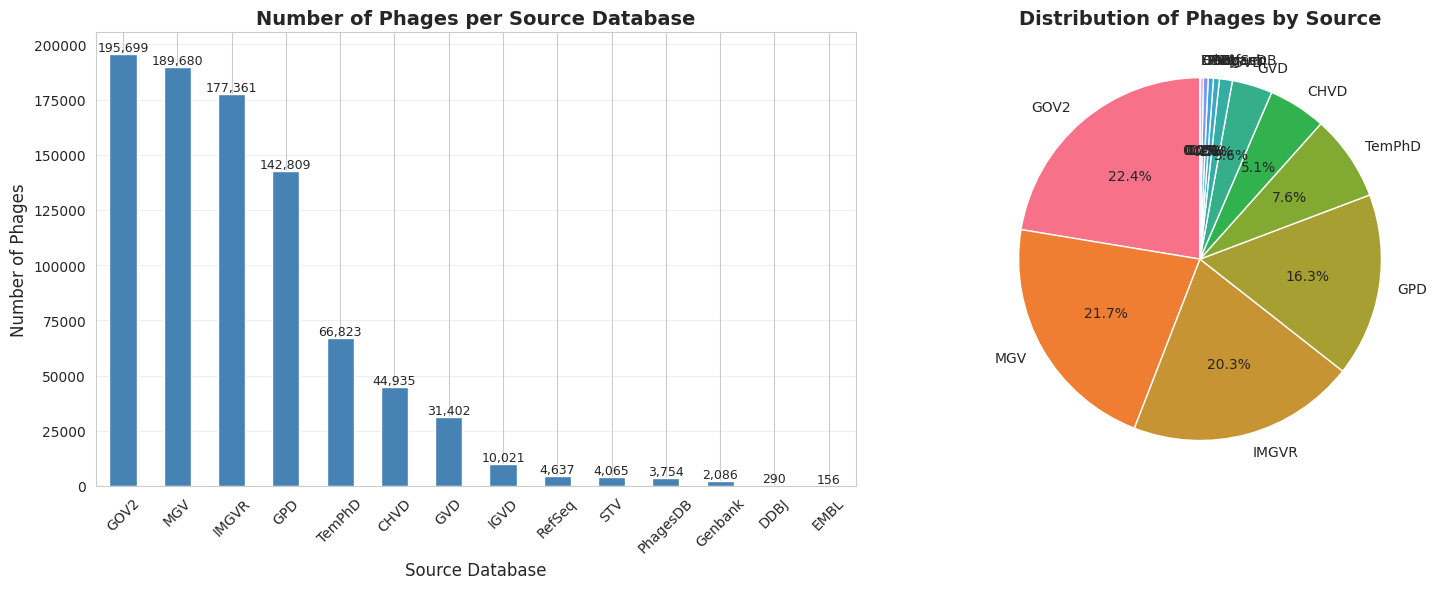

In [17]:
# Get phage metadata
phage_metadata = retriever.get_phage_metadata()

# Count entries per source
source_counts = phage_metadata['Source_DB'].value_counts().sort_values(ascending=False)

print("\n Phage Entries per Source Database:")
print("="*50)
source_df = pd.DataFrame({
    'Source Database': source_counts.index,
    'Count': source_counts.values,
    'Percentage': (source_counts.values / source_counts.sum() * 100).round(2)
})
print(source_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

source_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Number of Phages per Source Database', fontsize=14, fontweight='bold')
ax1.set_xlabel('Source Database', fontsize=12)
ax1.set_ylabel('Number of Phages', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(source_counts.values):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

colors = sns.color_palette('husl', len(source_counts))
ax2.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Distribution of Phages by Source', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Private Data: `test_private` Source

The `test_private` directory inside `private_data/` ships with the repository as a worked example.
When the pipeline is run, those 5 phage-host pairs are ingested alongside the public PhageScope data.

The cells below filter the database for entries whose `Source_DB` equals `test_private` and inspect:
- Which phages and hosts are present
- Their interaction types (virulent / temperate)
- Any extra attributes captured from optional CSV columns


In [ ]:
# ── Filter for the test_private source ─────────────────────────────────────
private_phages = retriever.get_phage_metadata(
    where_clause="Source_DB = 'test_private'"
)

print(f"Private phages (test_private): {len(private_phages)}")
if len(private_phages) > 0:
    print("
All private phage IDs:")
    print(private_phages['Phage_ID'].tolist())

    print("
Lifestyle / interaction distribution:")
    lifestyle_col = 'Lifestyle' if 'Lifestyle' in private_phages.columns else 'interaction'
    if lifestyle_col in private_phages.columns:
        print(private_phages[lifestyle_col].value_counts(dropna=False))
    else:
        print("No lifestyle/interaction column found.")

    print("
📋 Private phage metadata (non-empty columns):")
    preferred_cols = [
        'Phage_ID', 'Source_DB', 'Host', 'Lifestyle',
        'Length', 'GC_content', 'Taxonomy', 'Completeness', 'Cluster', 'Subcluster'
    ]
    existing_cols = [c for c in preferred_cols if c in private_phages.columns]
    private_display = private_phages[existing_cols].copy()
    key_cols = {'Phage_ID', 'Source_DB', 'Host', 'Lifestyle'}
    non_empty_cols = [c for c in private_display.columns if c in key_cols or private_display[c].notna().any()]
    private_display = private_display[non_empty_cols].fillna('N/A')
    display(private_display)

    # Optional columns from private metadata.csv are stored in private_entity_attributes
    try:
        attrs = retriever.conn.execute("""
            SELECT entity_id, attribute_key, attribute_value
            FROM private_entity_attributes
            WHERE Source_DB = 'test_private' AND entity_type = 'interaction'
        """).fetchdf()

        if len(attrs) > 0:
            print("
📋 Extra private attributes from metadata.csv:")
            attrs_wide = (
                attrs.pivot_table(
                    index='entity_id',
                    columns='attribute_key',
                    values='attribute_value',
                    aggfunc='first'
                )
                .reset_index()
            )
            attrs_wide[['Phage_ID', 'Host_ID']] = attrs_wide['entity_id'].str.split('|', n=1, expand=True)
            attrs_wide = attrs_wide.drop(columns=['entity_id'])
            front_cols = ['Phage_ID', 'Host_ID']
            other_cols = [c for c in attrs_wide.columns if c not in front_cols]
            attrs_wide = attrs_wide[front_cols + other_cols]
            display(attrs_wide)
    except Exception as e:
        print(f"Note: could not query private_entity_attributes ({e})")
else:
    print("⚠️  No test_private phages found.")
    print("   Make sure the pipeline has been run with private_data/test_private/ present.")

# ── Filter phage-host pairs for test_private ────────────────────────────────
try:
    private_pairs = retriever.get_phage_host_metadata(
        where_clause="p.Source_DB = 'test_private'"
    )
    print(f"
Private phage-host pairs: {len(private_pairs)}")
    if len(private_pairs) > 0:
        cols = [c for c in ['Phage_ID', 'Host_ID', 'Host_Species', 'Host_name', 'Interaction_Type']
                if c in private_pairs.columns]
        display(private_pairs[cols].head(10))
except Exception as e:
    print(f"Note: {e}")



## 2. Hosts in Phage Table vs. Available Host Genomes

This section answers a key question: **how many phages have a sequenced host genome available?**

The phage table records the host organism (e.g., "Escherichia coli"), but a downloadable host genome requires:
1. The host species being in NCBI/RefSeq with a genome assembly
2. The genome being downloaded as part of the PBI pipeline

**Expected behavior:** Many phages will *not* have a host genome available. This is normal — some hosts are unsequenced, some assemblies are unavailable, and some hosts may be recorded at a genus level without a matching genome.

2026-04-15 11:09:06,730 - INFO - 🔍 Querying host metadata...
2026-04-15 11:09:06,743 - INFO - ✅ Retrieved metadata for 5,542 hosts
2026-04-15 11:09:06,746 - INFO - 🔍 Querying phage-host metadata...
2026-04-15 11:09:09,014 - INFO - ✅ Retrieved metadata for 782,068 phage-host pairs



 Host Genome Coverage Analysis:
Unique hosts mentioned in phage table: 13,802
Hosts with available genomes: 5,416
Phage-host associations: 782,068
Unique phages in associations: 770,986
Unique hosts in associations: 5,542


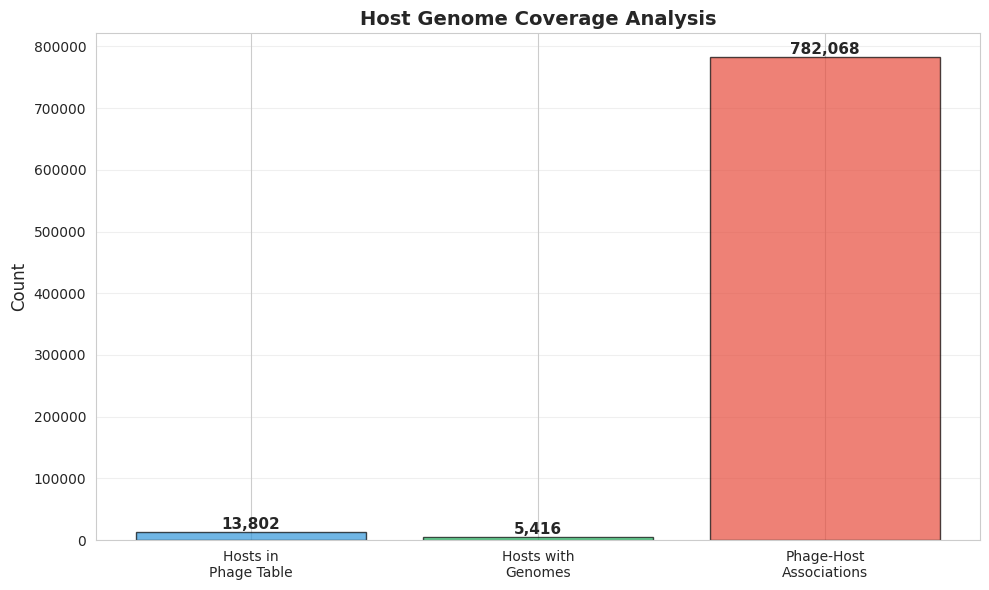

In [18]:
# Get unique hosts mentioned in phage table
hosts_in_phage_table = phage_metadata['Host'].dropna().unique()

# Get hosts with available genomes
try:
    host_metadata = retriever.get_host_metadata()
    hosts_with_genomes = host_metadata['Species_Name'].unique()

    # Get phage-host associations
    phage_host_pairs = retriever.get_phage_host_metadata()

    print("\n Host Genome Coverage Analysis:")
    print("="*50)
    print(f"Unique hosts mentioned in phage table: {len(hosts_in_phage_table):,}")
    print(f"Hosts with available genomes: {len(hosts_with_genomes):,}")
    print(f"Phage-host associations: {len(phage_host_pairs):,}")
    print(f"Unique phages in associations: {phage_host_pairs['Phage_ID'].nunique():,}")
    print(f"Unique hosts in associations: {phage_host_pairs['Host_ID'].nunique():,}")

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    categories = ['Hosts in\nPhage Table', 'Hosts with\nGenomes', 'Phage-Host\nAssociations']
    values = [len(hosts_in_phage_table), len(hosts_with_genomes), len(phage_host_pairs)]
    colors = ['#3498db', '#2ecc71', '#e74c3c']

    bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Host Genome Coverage Analysis', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Host genome data not available: {e}")
    print("   Run the host genome download workflow first.")

## 3. Phage Quality (Completeness) Distribution

Phage genome completeness indicates how much of the phage genome was sequenced and assembled. This is critical for reliable analysis:

- **Complete**: Full genome sequence, suitable for most analyses
- **High-quality draft**: Nearly complete, reliable for most purposes
- **Medium/Low quality**: Fragmented or partial — use with caution
- **Not determined**: Quality not assessed

For machine learning, filtering to complete or high-quality genomes is recommended.


 Phage Completeness Distribution:
  Completeness  Count  Percentage
  High-quality 300137       34.35
   Low-quality 267050       30.56
Medium-quality 212175       24.28
      Complete  72668        8.32
Not-determined  21688        2.48


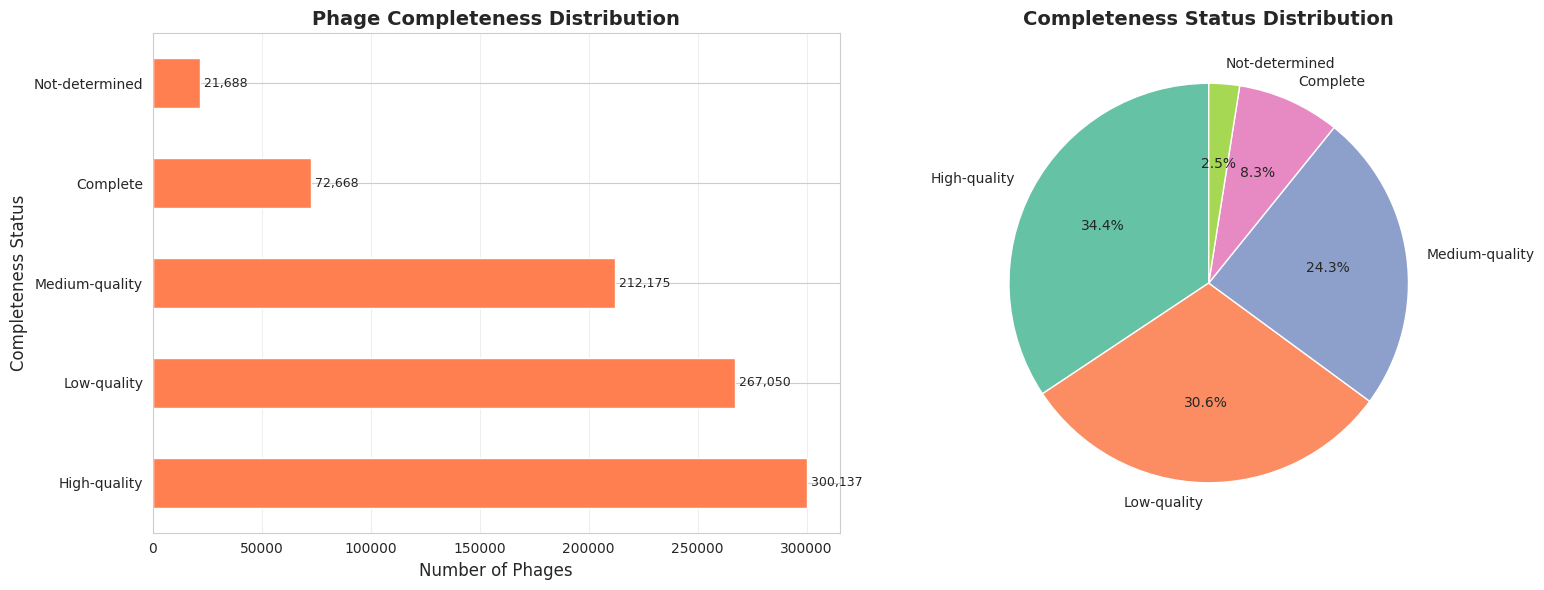

In [19]:
# Analyze completeness distribution
completeness_counts = phage_metadata['Completeness'].value_counts().sort_values(ascending=False)

print("\n Phage Completeness Distribution:")
print("="*50)
completeness_df = pd.DataFrame({
    'Completeness': completeness_counts.index,
    'Count': completeness_counts.values,
    'Percentage': (completeness_counts.values / completeness_counts.sum() * 100).round(2)
})
print(completeness_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

completeness_counts.plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Phage Completeness Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Phages', fontsize=12)
ax1.set_ylabel('Completeness Status', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(completeness_counts.values):
    ax1.text(v, i, f' {v:,}', va='center', fontsize=9)

colors = sns.color_palette('Set2', len(completeness_counts))
ax2.pie(completeness_counts.values, labels=completeness_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Completeness Status Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Phage Lifestyle Distribution

Phage lifestyle describes how a phage interacts with its host:

- **Lytic (virulent)**: The phage always kills the host cell immediately after replication
- **Lysogenic (temperate)**: The phage integrates into the host genome and may remain dormant
- **Unknown/Chronic**: Other lifestyles including chronic infection

Lifestyle is important for therapeutic applications — lytic phages are preferred for phage therapy as they reliably kill bacteria.


 Phage Lifestyle Distribution:
Lifestyle  Count  Percentage
 virulent 553688       63.37
temperate 320030       36.63


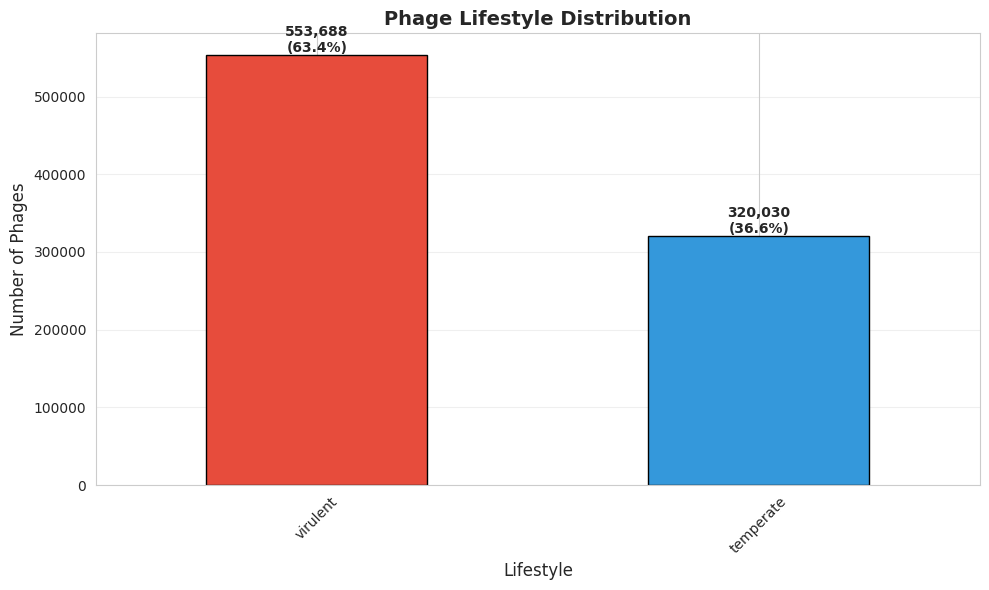

In [20]:
# Analyze lifestyle distribution
lifestyle_counts = phage_metadata['Lifestyle'].value_counts()

print("\n Phage Lifestyle Distribution:")
print("="*50)
lifestyle_df = pd.DataFrame({
    'Lifestyle': lifestyle_counts.index,
    'Count': lifestyle_counts.values,
    'Percentage': (lifestyle_counts.values / lifestyle_counts.sum() * 100).round(2)
})
print(lifestyle_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#95a5a6']
lifestyle_counts.plot(kind='bar', ax=ax, color=colors[:len(lifestyle_counts)], edgecolor='black')
ax.set_title('Phage Lifestyle Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Lifestyle', fontsize=12)
ax.set_ylabel('Number of Phages', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(lifestyle_counts.values):
    ax.text(i, v, f'{v:,}\n({lifestyle_counts.values[i]/lifestyle_counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Phage Genome Length Distribution

Phage genome sizes vary enormously:
- **Small phages**: 3-10 kb (e.g., ssDNA phages like phiX174)
- **Medium phages**: 10-100 kb (most common dsDNA phages)
- **Large/jumbo phages**: >100 kb (e.g., some T4-like phages can reach ~500 kb)

The distribution shape tells us about database composition. A right-skewed distribution is typical.


 Phage Genome Length Statistics:
Mean length: 37,564 bp
Median length: 33,982 bp
Min length: 203 bp
Max length: 553,716 bp
Std deviation: 28,655 bp


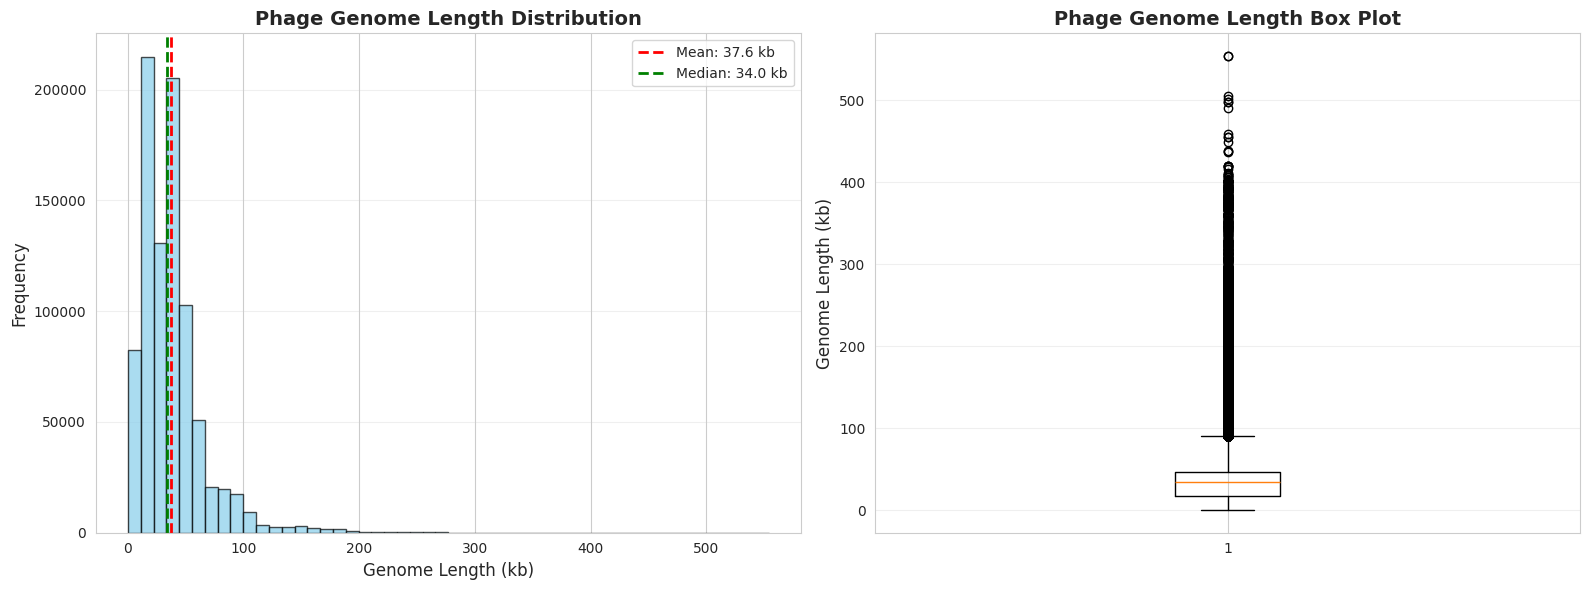

In [21]:
# Analyze genome length distribution
lengths = phage_metadata['Length'].dropna()

print("\n Phage Genome Length Statistics:")
print("="*50)
print(f"Mean length: {lengths.mean():,.0f} bp")
print(f"Median length: {lengths.median():,.0f} bp")
print(f"Min length: {lengths.min():,.0f} bp")
print(f"Max length: {lengths.max():,.0f} bp")
print(f"Std deviation: {lengths.std():,.0f} bp")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(lengths/1000, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(lengths.mean()/1000, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {lengths.mean()/1000:.1f} kb')
ax1.axvline(lengths.median()/1000, color='green', linestyle='--', linewidth=2,
            label=f'Median: {lengths.median()/1000:.1f} kb')
ax1.set_xlabel('Genome Length (kb)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Phage Genome Length Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2.boxplot(lengths/1000, vert=True)
ax2.set_ylabel('Genome Length (kb)', fontsize=12)
ax2.set_title('Phage Genome Length Box Plot', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. GC Content Analysis

GC content (percentage of guanine + cytosine bases) is a fundamental genomic property:

- **Phage GC content** reflects their evolutionary origin and host adaptation
- **Host GC content** is a taxonomic signature — Firmicutes tend to be AT-rich (~30-40% GC), Actinobacteria tend to be GC-rich (~60-75% GC)
- A correlation between phage and host GC content suggests co-evolution

The GC content difference between phage and host is a useful feature for host-range prediction.


 Phage GC Content Statistics:
Mean GC%: 44.19%
Median GC%: 43.13%
Min GC%: 17.92%
Max GC%: 78.50%
Std deviation: 9.14%


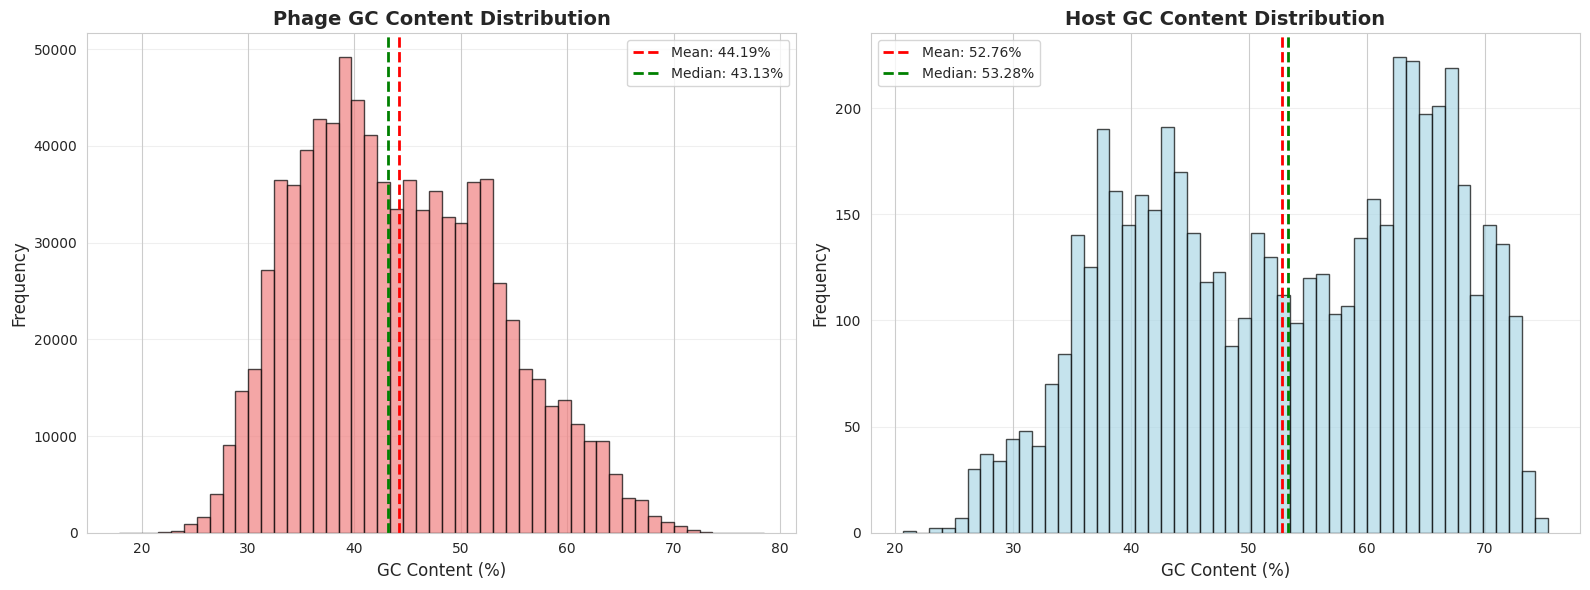

In [22]:
# Analyze GC content distribution
gc_content = phage_metadata['GC_content'].dropna()

print("\n Phage GC Content Statistics:")
print("="*50)
print(f"Mean GC%: {gc_content.mean():.2f}%")
print(f"Median GC%: {gc_content.median():.2f}%")
print(f"Min GC%: {gc_content.min():.2f}%")
print(f"Max GC%: {gc_content.max():.2f}%")
print(f"Std deviation: {gc_content.std():.2f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(gc_content, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax1.axvline(gc_content.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {gc_content.mean():.2f}%')
ax1.axvline(gc_content.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {gc_content.median():.2f}%')
ax1.set_xlabel('GC Content (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Phage GC Content Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

try:
    host_gc = host_metadata['GC_Content'].dropna()
    ax2.hist(host_gc, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    ax2.axvline(host_gc.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {host_gc.mean():.2f}%')
    ax2.axvline(host_gc.median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: {host_gc.median():.2f}%')
    ax2.set_xlabel('GC Content (%)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Host GC Content Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
except Exception:
    ax2.text(0.5, 0.5, 'Host data not available',
             ha='center', va='center', transform=ax2.transAxes, fontsize=14)
    ax2.set_title('Host GC Content Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Host Taxonomy Analysis

Understanding host diversity tells us about the range of bacteria that phages in this database infect. A database biased toward a few host genera (e.g., *Escherichia*, *Mycobacterium*) may produce biased ML models.

**Key metrics to check:**
- Number of distinct species
- Distribution of phages per host species
- Whether the most common hosts are well-represented biologically or just heavily studied (sampling bias)


 Top 20 Host Species:
 1. Escherichia coli                                      18
 2. Salmonella enterica                                   14
 3. uncultured Clostridium sp.                            11
 4. uncultured Blautia sp.                                 7
 5. Prochlorococcus marinus                                7
 6. uncultured Ruminococcus sp.                            5
 7. Bacillus thuringiensis                                 5
 8. uncultured Eubacterium sp.                             4
 9. Enterococcus faecalis                                  3
10. Staphylococcus aureus                                  3
11. Enterobacter hormaechei                                3
12. Xanthomonas oryzae                                     3
13. Vibrio cholerae                                        3
14. Paenibacillus polymyxa                                 2
15. uncultured Roseburia sp.                               2
16. Bacillus subtilis                                      2
1

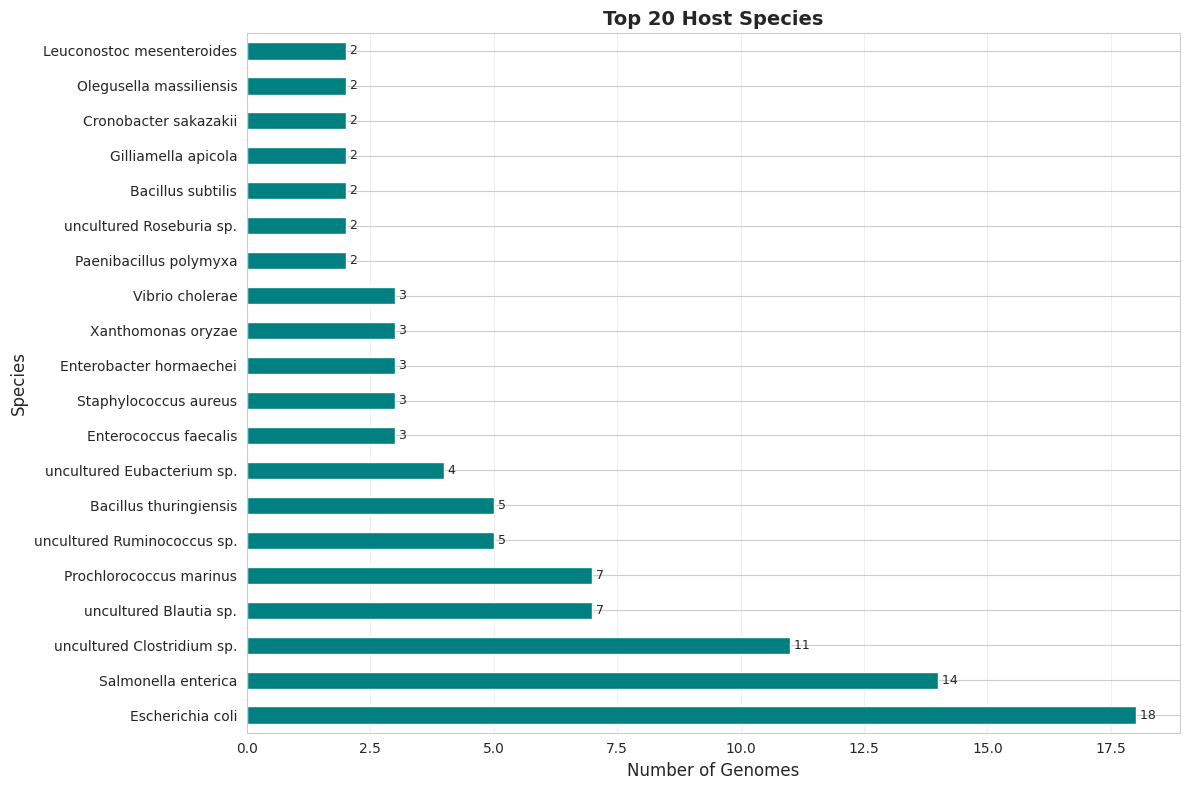

In [23]:
try:
    # Analyze host species distribution
    species_counts = host_metadata['Species_Name'].value_counts().head(20)

    print("\n Top 20 Host Species:")
    print("="*50)
    for i, (species, count) in enumerate(species_counts.items(), 1):
        print(f"{i:2d}. {species:50s} {count:5d}")

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    species_counts.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 20 Host Species', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Genomes', fontsize=12)
    ax.set_ylabel('Species', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(species_counts.values):
        ax.text(v, i, f' {v}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Host taxonomy analysis not available: {e}")

## 8. Host Assembly Quality Distribution

NCBI assembly levels indicate genome completeness for host bacteria:
- **Complete Genome**: Fully assembled chromosome(s), highest quality
- **Chromosome**: Nearly complete with minor gaps
- **Scaffold**: Multiple contigs ordered but with gaps
- **Contig**: Unordered contigs, most fragmented

For sequence-based ML analyses, prefer **Complete Genome** or **Chromosome** assemblies for reliable results.


 Host Assembly Level Distribution:
 Assembly Level  Count  Percentage
Complete Genome   2169       39.14
       Scaffold   1705       30.77
         Contig   1554       28.04
     Chromosome    114        2.06


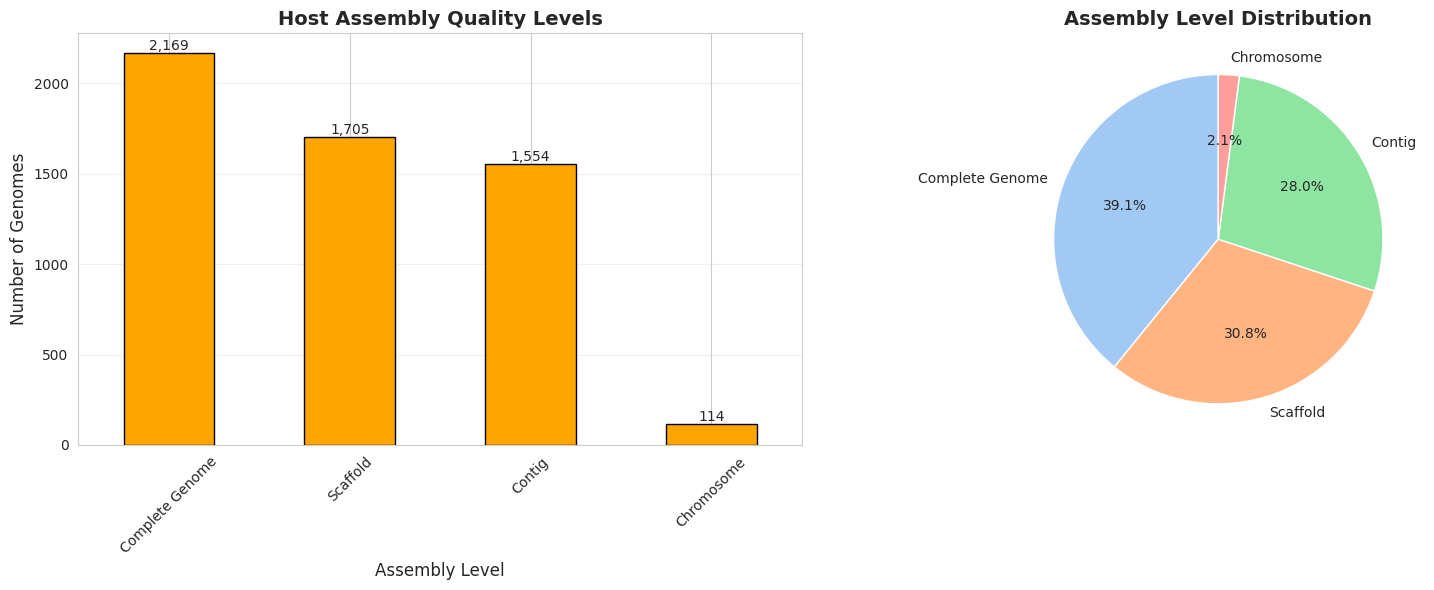

In [24]:
try:
    # Analyze assembly level distribution
    assembly_counts = host_metadata['Assembly_Level'].value_counts()

    print("\n Host Assembly Level Distribution:")
    print("="*50)
    assembly_df = pd.DataFrame({
        'Assembly Level': assembly_counts.index,
        'Count': assembly_counts.values,
        'Percentage': (assembly_counts.values / assembly_counts.sum() * 100).round(2)
    })
    print(assembly_df.to_string(index=False))

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    assembly_counts.plot(kind='bar', ax=ax1, color='orange', edgecolor='black')
    ax1.set_title('Host Assembly Quality Levels', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Assembly Level', fontsize=12)
    ax1.set_ylabel('Number of Genomes', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    for i, v in enumerate(assembly_counts.values):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

    colors = sns.color_palette('pastel', len(assembly_counts))
    ax2.pie(assembly_counts.values, labels=assembly_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
    ax2.set_title('Assembly Level Distribution', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Assembly quality analysis not available: {e}")

## 9. Phage-Host Pair Analysis

Phage-host associations are the core of the database — these are experimentally validated infection pairs. Analyzing their properties helps understand:

- Which phage lifestyles are most studied in host-interaction contexts
- Which host assembly qualities are available for paired analyses
- Which host species are best represented with paired phage data

**Note:** Not every phage in the database has a paired host genome. Pairs here represent phages with *both* a metadata record AND a host with a genome sequence.


 Phage-Host Pair Statistics:

Phage Lifestyle in Pairs:
  virulent: 505,149 (64.6%)
  temperate: 276,919 (35.4%)

Top 10 Phage Sources in Pairs:
  GOV2: 193,311
  MGV: 155,886
  IMGVR: 145,366
  GPD: 141,708
  TemPhD: 64,915
  CHVD: 30,417
  GVD: 29,263
  IGVD: 6,334
  RefSeq: 4,557
  STV: 4,052

Host Assembly Level in Pairs:
  Complete Genome: 654,646 (83.7%)
  Contig: 64,485 (8.2%)
  Scaffold: 43,644 (5.6%)
  Chromosome: 19,293 (2.5%)


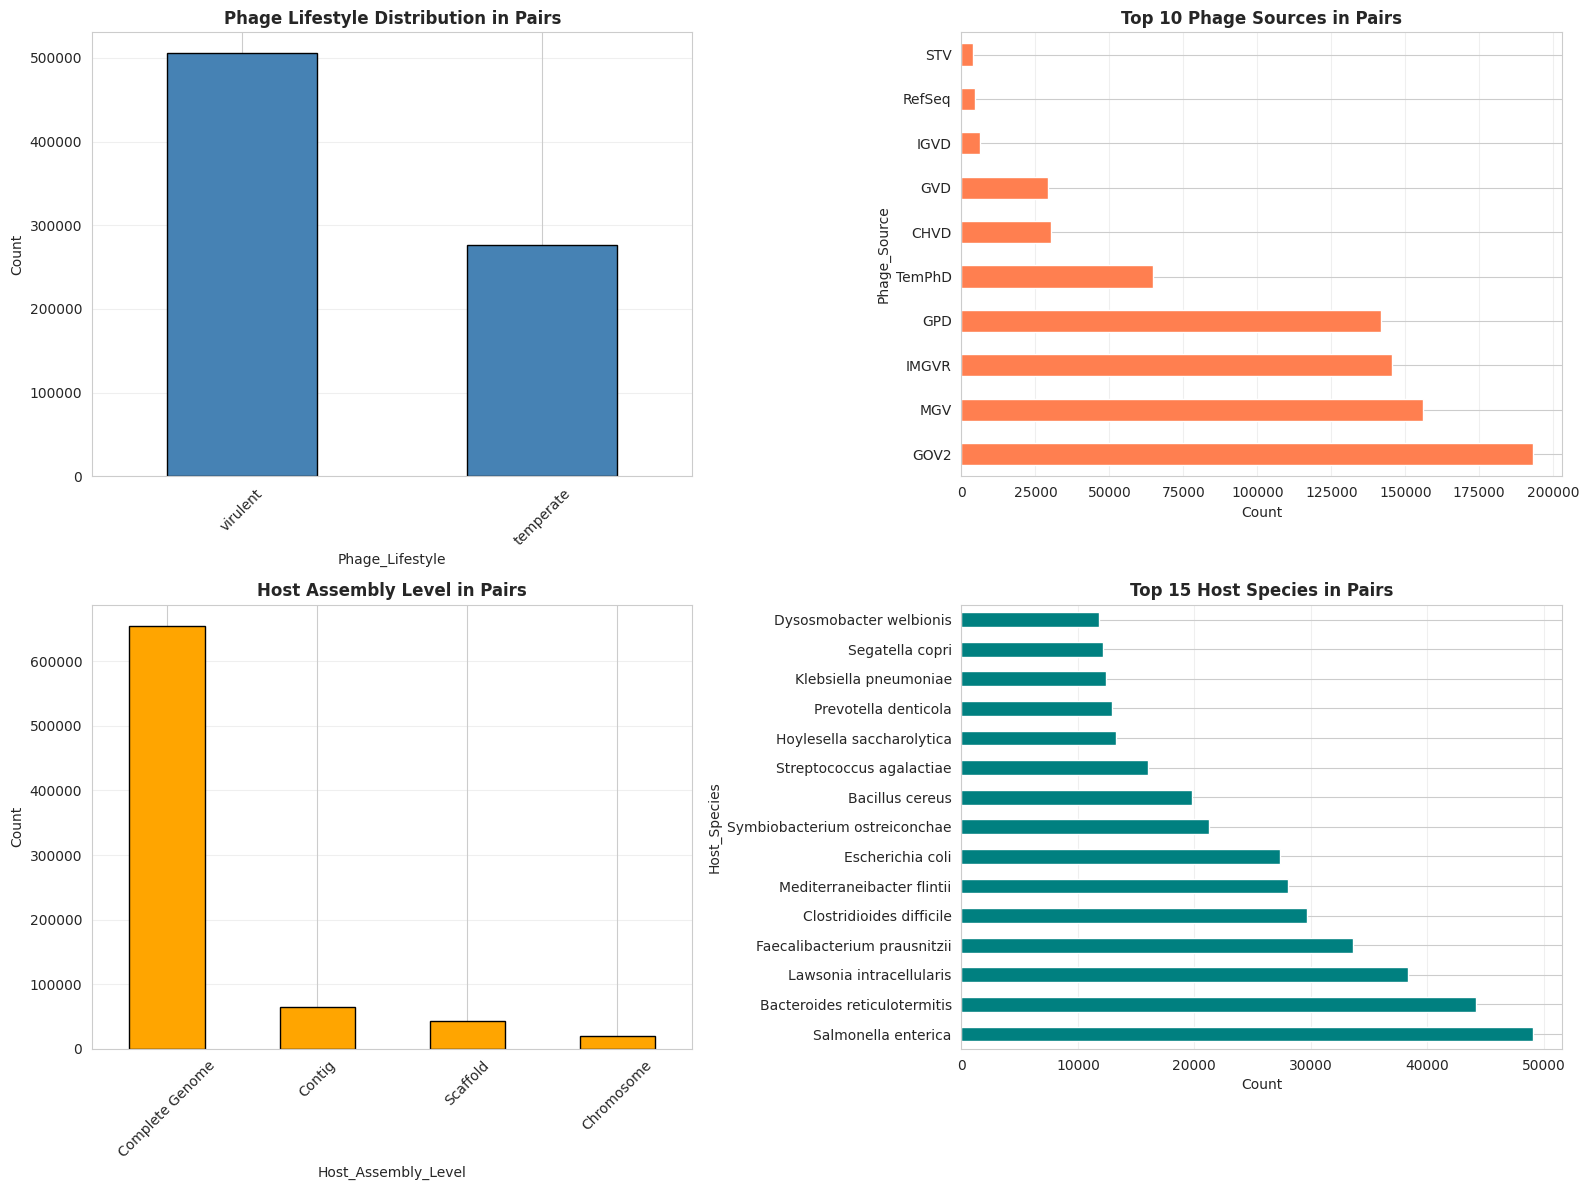

In [25]:
try:
    # Analyze phage-host metadata
    print("\n Phage-Host Pair Statistics:")
    print("="*50)

    # Lifestyle distribution in pairs
    pair_lifestyle = phage_host_pairs['Phage_Lifestyle'].value_counts()
    print("\nPhage Lifestyle in Pairs:")
    for lifestyle, count in pair_lifestyle.items():
        print(f"  {lifestyle}: {count:,} ({count/len(phage_host_pairs)*100:.1f}%)")

    # Source distribution in pairs
    pair_source = phage_host_pairs['Phage_Source'].value_counts().head(10)
    print("\nTop 10 Phage Sources in Pairs:")
    for source, count in pair_source.items():
        print(f"  {source}: {count:,}")

    # Assembly level distribution in pairs
    pair_assembly = phage_host_pairs['Host_Assembly_Level'].value_counts()
    print("\nHost Assembly Level in Pairs:")
    for level, count in pair_assembly.items():
        print(f"  {level}: {count:,} ({count/len(phage_host_pairs)*100:.1f}%)")

    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    pair_lifestyle.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
    axes[0,0].set_title('Phage Lifestyle Distribution in Pairs', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Count', fontsize=10)
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].grid(axis='y', alpha=0.3)

    pair_source.plot(kind='barh', ax=axes[0,1], color='coral')
    axes[0,1].set_title('Top 10 Phage Sources in Pairs', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Count', fontsize=10)
    axes[0,1].grid(axis='x', alpha=0.3)

    pair_assembly.plot(kind='bar', ax=axes[1,0], color='orange', edgecolor='black')
    axes[1,0].set_title('Host Assembly Level in Pairs', fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel('Count', fontsize=10)
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(axis='y', alpha=0.3)

    top_hosts = phage_host_pairs['Host_Species'].value_counts().head(15)
    top_hosts.plot(kind='barh', ax=axes[1,1], color='teal')
    axes[1,1].set_title('Top 15 Host Species in Pairs', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Count', fontsize=10)
    axes[1,1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Phage-host pair analysis not available: {e}")

## 10. Understanding Warnings About Missing Sequences

When using `retriever.get_phage_host_pairs()` or the streaming datasets, you may see warnings like:

```
Host genome not found in FASTA: GCF_000123456.1
Phage sequence not found: PHAGE_XYZ_001
```

**This is expected and normal.** Here's why:

### Three distinct populations:
1. **Phages with hosts** (in `phage_host_associations` table): Phages with a recorded host, but the host genome may or may not be downloaded
2. **Phages without hosts** (in `fact_phages` but not in associations): No known host - cannot form pairs
3. **Hosts without genomes** (in `dim_hosts` but FASTA missing): Host metadata exists but genome download failed or was not attempted

### What the pipeline does:
- It automatically **skips** pairs where sequences are missing and logs a warning
- It continues processing remaining pairs normally
- Missing pairs can be tracked using `missing_hosts_csv` parameter

### How to reduce missing warnings:
- Re-run the host genome download pipeline to retry failed downloads
- Filter to well-covered hosts: `where_clause="Assembly_Level = 'Complete Genome'"`
- Check `data/logs/failed_downloads.txt` for systematic failures

In [26]:
# Diagnostic: count phages with and without host associations
print("Phage-Host Association Coverage:")
print("="*50)

total_phages = len(phage_metadata)
print(f"Total phages in database: {total_phages:,}")

try:
    phages_with_hosts = phage_host_pairs['Phage_ID'].nunique()
    phages_without_hosts = total_phages - phages_with_hosts
    print(f"Phages with host associations: {phages_with_hosts:,} ({phages_with_hosts/total_phages*100:.1f}%)")
    print(f"Phages without host associations: {phages_without_hosts:,} ({phages_without_hosts/total_phages*100:.1f}%)")

    try:
        hosts_in_db = len(host_metadata)
        print(f"\nHost genomes in database: {hosts_in_db:,}")
        print(f"Hosts in associations: {phage_host_pairs['Host_ID'].nunique():,}")
    except Exception:
        pass

    print("\nTip: Missing sequences are normal. Use missing_hosts_csv parameter")
    print("   in streaming datasets to track which pairs are skipped.")
except Exception as e:
    print(f"Could not compute coverage: {e}")

Phage-Host Association Coverage:
Total phages in database: 873,718
Phages with host associations: 770,986 (88.2%)
Phages without host associations: 102,732 (11.8%)

Host genomes in database: 5,542
Hosts in associations: 5,542

Tip: Missing sequences are normal. Use missing_hosts_csv parameter
   in streaming datasets to track which pairs are skipped.


## Summary

This notebook provided a comprehensive quality control analysis of the PBI database:

- **Source database distribution** - which databases contribute phages and in what proportions
- **Host genome coverage** - the gap between phages with recorded hosts vs. downloadable genomes
- **Phage quality metrics** - completeness, lifestyle, genome length distributions
- **GC content** - phage and host GC distributions for co-evolution analysis
- **Host taxonomy** - species diversity and assembly quality
- **Phage-host pairs** - properties of validated infection pairs
- **Missing sequence warnings** - explained and contextualized

### Next Steps
- See `02_sequence_retrieval.ipynb` to learn how to retrieve sequences
- See `03_ml_streaming.ipynb` to build ML models from this data
- Use these visualizations to identify quality filters for your analyses

In [27]:
# Close database connection
retriever.close()
print("Database connection closed")

2026-04-15 11:09:15,056 - INFO - 🔒 Database connection closed


Database connection closed
